In [6]:
# Cell 1 - Imports & Test
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Test - download Apple stock data
ticker = yf.Ticker("AAPL")
df = ticker.history(period="1y")
print(df.shape)
print(df.tail(3))

(252, 7)
                                 Open        High         Low       Close  \
Date                                                                        
2026-05-01 00:00:00-04:00  278.859985  287.220001  278.369995  280.140015   
2026-05-04 00:00:00-04:00  279.660004  280.630005  274.859985  276.829987   
2026-05-05 00:00:00-04:00  276.899994  284.570007  276.501007  283.975006   

                             Volume  Dividends  Stock Splits  
Date                                                          
2026-05-01 00:00:00-04:00  79915400        0.0           0.0  
2026-05-04 00:00:00-04:00  46638000        0.0           0.0  
2026-05-05 00:00:00-04:00  27048430        0.0           0.0  


In [5]:
# Cell 2 - Define Your Portfolio (fixed date range)
tickers = ["AAPL", "MSFT", "JPM", "GS", "SPY"]

# Use explicit dates instead of period="1y"
prices = yf.download(tickers, start="2024-01-01", end="2025-05-01", auto_adjust=True)["Close"]

print(prices.shape)
print(prices.head(3))
print(prices.tail(3))

[*********************100%***********************]  5 of 5 completed

(333, 5)
Ticker            AAPL          GS         JPM        MSFT         SPY
Date                                                                  
2024-01-02  183.731293  369.588867  163.009354  364.589447  459.991180
2024-01-03  182.355606  363.392639  162.298889  364.324066  456.234619
2024-01-04  180.039642  364.496704  163.375916  361.709045  454.765045
Ticker            AAPL          GS         JPM        MSFT         SPY
Date                                                                  
2025-04-28  209.228104  535.309998  238.580093  388.188202  544.606873
2025-04-29  210.293457  537.778809  239.953384  391.046295  548.037537
2025-04-30  211.577850  536.436707  239.953384  392.257019  548.255066


In [5]:
prices.head()

Ticker,AAPL,GS,JPM,MSFT,SPY
Date,,,,,
2024-01-02,183.731308,369.588898,163.009354,364.589447,459.991211
2024-01-03,182.355591,363.392578,162.298874,364.324036,456.234589
2024-01-04,180.039658,364.496674,163.375916,361.709076,454.765015
2024-01-05,179.317154,367.818481,164.195587,361.522278,455.387939
2024-01-08,183.652130,370.121918,163.957336,368.344727,461.888977


In [7]:
# Cell 3 - Daily Returns
# Pct_change calculates the % change from one day to the next
daily_returns = prices.pct_change().dropna()

print(daily_returns.shape)
print(daily_returns.tail(3))

# Quick stats - this is called "descriptive statistics"
print("\n--- Summary Statistics ---")
print(daily_returns.describe().round(4))

(332, 5)
Ticker          AAPL        GS       JPM      MSFT       SPY
Date                                                        
2025-04-28  0.004109  0.002826 -0.001355 -0.001761  0.000381
2025-04-29  0.005092  0.004612  0.005756  0.007363  0.006299
2025-04-30  0.006108 -0.002496  0.000000  0.003096  0.000397

--- Summary Statistics ---
Ticker      AAPL        GS       JPM      MSFT       SPY
count   332.0000  332.0000  332.0000  332.0000  332.0000
mean      0.0006    0.0013    0.0013    0.0003    0.0006
std       0.0190    0.0196    0.0166    0.0148    0.0115
min      -0.0925   -0.0921   -0.0748   -0.0618   -0.0585
25%      -0.0072   -0.0071   -0.0060   -0.0068   -0.0032
50%       0.0016    0.0008    0.0017    0.0007    0.0010
75%       0.0099    0.0107    0.0092    0.0092    0.0060
max       0.1533    0.1310    0.1154    0.1013    0.1050


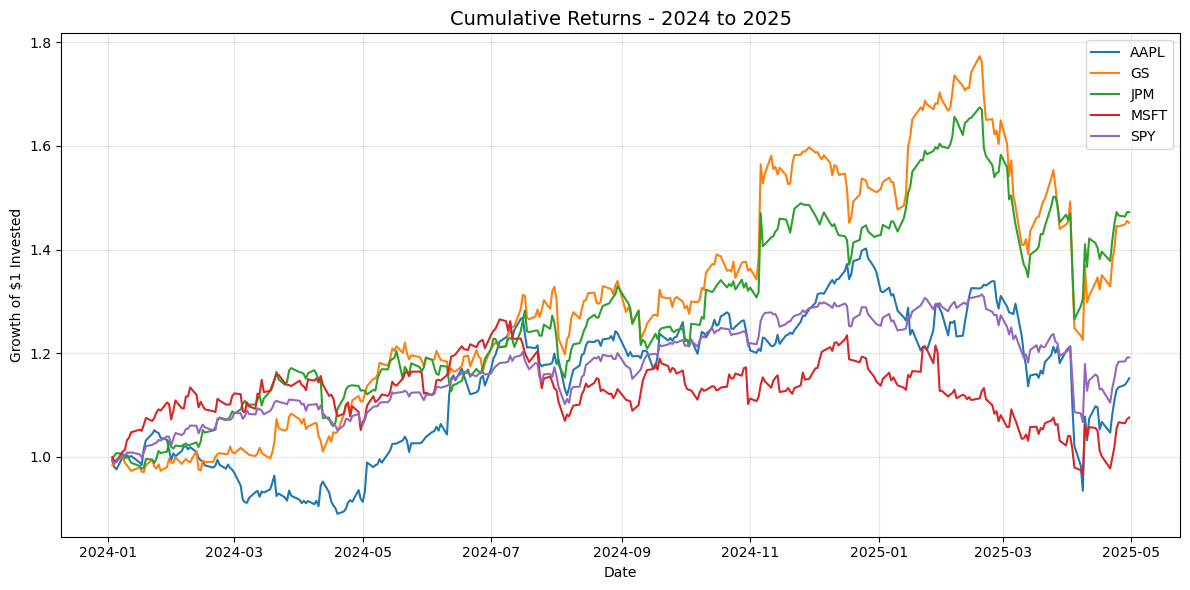

In [8]:
# Cell 4 - Cumulative Returns Chart
# This shows how $1 invested in each stock grew over time

cumulative_returns = (1 + daily_returns).cumprod()

plt.figure(figsize=(12, 6))

for column in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[column], label=column)

plt.title("Cumulative Returns - 2024 to 2025", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Cell 5 - Sharpe Ratio (Risk-Adjusted Return)
# This answers: "How much return am I getting per unit of risk?"

risk_free_rate = 0.0525 / 252  # ~5.25% annual T-bill rate, converted to daily

sharpe_ratios = (daily_returns.mean() - risk_free_rate) / daily_returns.std()

# Annualize it (multiply by square root of 252 trading days)
sharpe_annual = sharpe_ratios * np.sqrt(252)

print("--- Annualized Sharpe Ratios ---")
print(sharpe_annual.round(3).sort_values(ascending=False))
print("\nGeneral guide:")
print("> 1.0 = Good | > 2.0 = Great | < 0 = Worse than T-bills")

--- Annualized Sharpe Ratios ---
Ticker
JPM     1.045
GS      0.896
SPY     0.531
AAPL    0.330
MSFT    0.130
dtype: float64

General guide:
> 1.0 = Good | > 2.0 = Great | < 0 = Worse than T-bills


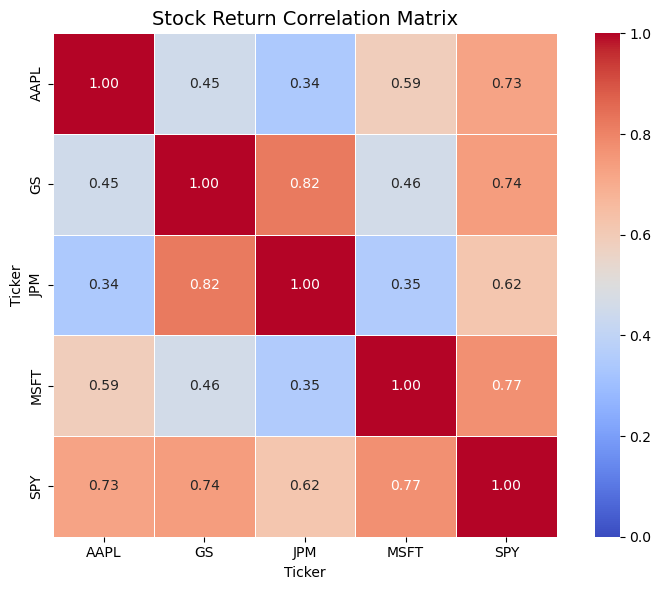

In [10]:
# Cell 6 - Correlation Heatmap
# This shows how stocks move in relation to each other
# Key concept: diversification = low correlation between holdings

import seaborn as sns

correlation_matrix = daily_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Show the numbers inside each cell
    fmt=".2f",           # Round to 2 decimal places
    cmap="coolwarm",     # Red = high correlation, Blue = low
    vmin=0, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Stock Return Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Cell 7 - Portfolio Summary Dashboard

# --- Calculations ---
total_return = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
annual_vol = daily_returns.std() * np.sqrt(252) * 100
sharpe = sharpe_annual.round(3)
best_day = daily_returns.max() * 100
worst_day = daily_returns.min() * 100

# --- Build Summary Table ---
summary = pd.DataFrame({
    "Total Return (%)": total_return.round(2),
    "Annual Volatility (%)": annual_vol.round(2),
    "Sharpe Ratio": sharpe,
    "Best Day (%)": best_day.round(2),
    "Worst Day (%)": worst_day.round(2)
})

print("=" * 65)
print("        STOCK PORTFOLIO ANALYZER — SUMMARY REPORT")
print("=" * 65)
print(f"Period: 2024-01-02 to 2025-04-30  |  Assets Analyzed: {len(tickers)}")
print("-" * 65)
print(summary.to_string())
print("-" * 65)

# --- Winner Callouts ---
print(f"\n🏆 Best Total Return:     {total_return.idxmax()} ({total_return.max():.1f}%)")
print(f"⚡ Most Volatile:          {annual_vol.idxmax()} ({annual_vol.max():.1f}% ann. vol)")
print(f"📊 Best Risk-Adjusted:    {sharpe.idxmax()} (Sharpe: {sharpe.max():.3f})")
print(f"📉 Worst Single Day:      {worst_day.idxmin()} ({worst_day.min():.2f}%)")
print("=" * 65)

        STOCK PORTFOLIO ANALYZER — SUMMARY REPORT
Period: 2024-01-02 to 2025-04-30  |  Assets Analyzed: 5
-----------------------------------------------------------------
        Total Return (%)  Annual Volatility (%)  Sharpe Ratio  Best Day (%)  Worst Day (%)
Ticker                                                                                    
AAPL               15.16                  30.15         0.330         15.33          -9.25
GS                 45.14                  31.04         0.896         13.10          -9.21
JPM                47.20                  26.40         1.045         11.54          -7.48
MSFT                7.59                  23.56         0.130         10.13          -6.18
SPY                19.19                  18.33         0.531         10.50          -5.85
-----------------------------------------------------------------

🏆 Best Total Return:     JPM (47.2%)
⚡ Most Volatile:          GS (31.0% ann. vol)
📊 Best Risk-Adjusted:    JPM (Sharpe: 1.0

In [12]:
print(summary.to_csv())

Ticker,Total Return (%),Annual Volatility (%),Sharpe Ratio,Best Day (%),Worst Day (%)
AAPL,15.16,30.15,0.33,15.33,-9.25
GS,45.14,31.04,0.896,13.1,-9.21
JPM,47.2,26.4,1.045,11.54,-7.48
MSFT,7.59,23.56,0.13,10.13,-6.18
SPY,19.19,18.33,0.531,10.5,-5.85

